# import lib & data

In [142]:
import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential
import pandas as pd

Notebook last run (end-to-end): 2026-04-27 14:36:01.465906


In [143]:
# Walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("dataset"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'dataset'.
There are 2 directories and 0 images in 'dataset\test'.
There are 0 directories and 20 images in 'dataset\test\CocoScale'.
There are 0 directories and 20 images in 'dataset\test\Healty'.
There are 2 directories and 0 images in 'dataset\train'.
There are 0 directories and 80 images in 'dataset\train\CocoScale'.
There are 0 directories and 80 images in 'dataset\train\Healty'.


In [144]:
data_dir = pathlib.Path("dataset/train") # turn our training path into a Python path
class_names = np.array(sorted([item.name for item in data_dir.glob('*')])) # created a list of class_names from the subdirectories
print(class_names)

['CocoScale' 'Healty']


In [145]:
# View an image
def view_random_image(target_dir, target_class):
  # Setup target directory (we'll view images from here)
  target_folder = target_dir+target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}") # show the shape of the image

  return img

Image shape: (100, 100, 3)


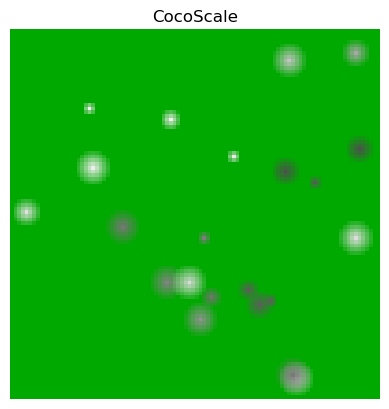

In [146]:
# View a random image from the training dataset
img = view_random_image(target_dir="dataset/train/",
                        target_class="CocoScale")

In [147]:
# Preprocess data (get all of the pixel values between 1 and 0, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Setup the train and test directories
train_dir = "dataset/train/"
test_dir = "dataset/test/"

# Turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(100, 100),
                                               class_mode='binary',
                                               batch_size=32)

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(100, 100),
                                             class_mode='binary',
                                             batch_size=32)

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


# plt

In [148]:
# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """ 
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

In [179]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=100):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [345]:
def pred_and_plot(model, filename, class_names):
  """
  Imports an image located at filename, makes a prediction on it with
  a trained model and plots the image with the predicted class as the title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)
  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))

  # Get the predicted class
  pred_class = class_names[int(tf.round(pred)[0][0])]
  
  # Calculate confidence percentage
  pred_prob = pred[0][0]  # Get the raw prediction probability

  if int(tf.round(pred)[0][0]) == 1:
    confidence = pred_prob * 100  # Confidence for class 1
  else:
    confidence = (1 - pred_prob) * 100  # Confidence for class 0

  # Plot the image and predicted class with confidence
  plt.figure(figsize=(5, 15))
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class} ({filename}: {confidence:.2f}% confident)")
  plt.axis(False);


# model 5

In [282]:
# Create the model (this can be our baseline, a 3 layer Convolutional Neural Network)
model_5 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(100, 100, 3)),
  MaxPool2D(pool_size=2), # reduce number of features by half
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation='sigmoid')
])

# Compile model (same as model_4)
model_5.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

# Fit the model
history_5 = model_5.fit(train_data,
                        epochs=20,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.4875 - loss: 0.6920 - val_accuracy: 0.9250 - val_loss: 0.6748
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.9125 - loss: 0.6652 - val_accuracy: 0.9750 - val_loss: 0.6255
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9750 - loss: 0.6020 - val_accuracy: 0.9500 - val_loss: 0.5412
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.9688 - loss: 0.5014 - val_accuracy: 0.9750 - val_loss: 0.4229
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.9937 - loss: 0.3630 - val_accuracy: 0.9750 - val_loss: 0.2883
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.9875 - loss: 0.2302 - val_accuracy: 0.9750 - val_loss: 0.1716
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.9875 - loss: 0.1234 - val_accuracy: 0.9750 - val_loss: 0.1021
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.9875 - loss: 0.0721 - val_accuracy: 0.9750 - val_loss: 

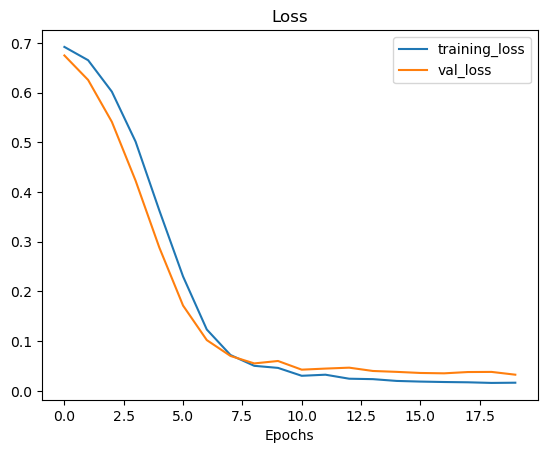

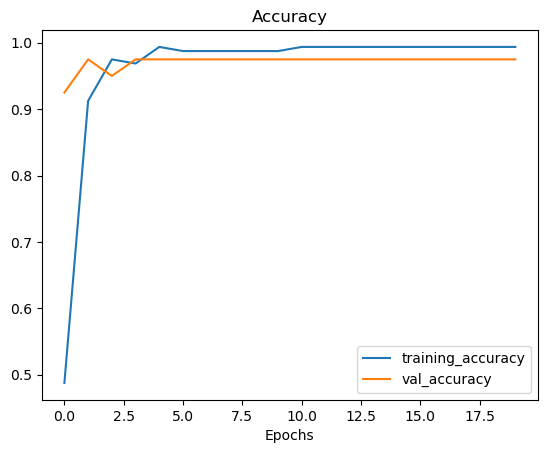

In [283]:
# Plot loss curves of model_5 results
plot_loss_curves(history_5)

# prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


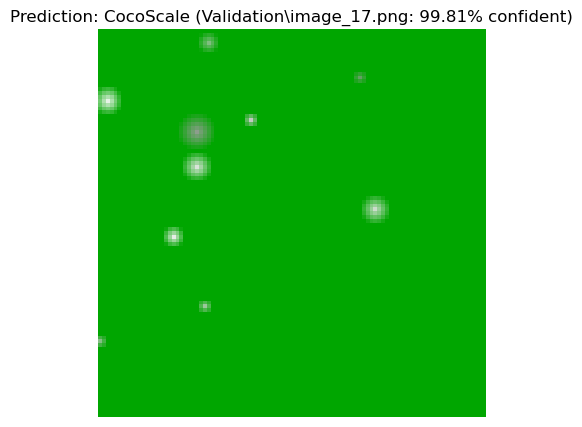

In [346]:

# Test our model on a custom image
select_image_1 = random.choice(os.listdir("Validation/"))
pred_1 = pred_and_plot(model_5, rf"Validation\{select_image_1}", class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


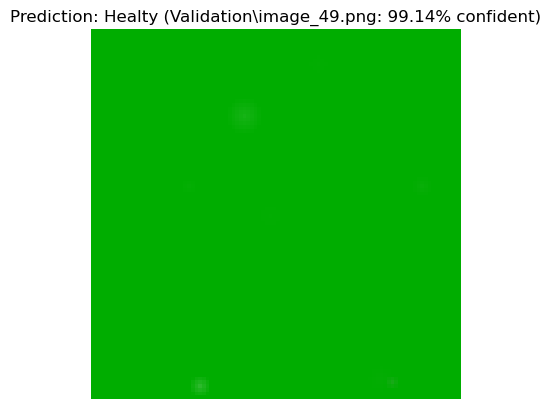

In [334]:
# Test our model on a custom image
select_image_2 = random.choice(os.listdir("Validation/"))
pred_2 = pred_and_plot(model_5, rf"Validation\{select_image_2}", class_names)